# 04 モデル改善実験

ここでは、特徴量を段階的に増やして、精度がどう変わるかを確認する

具体的には、以下の実験を行う

| 実験 | 内容 | 仮説 |
|-|-|-|
| v1 | 現在値のみ | 現在の気象状態だけである程度予測できる |
| v2 | ラグ特徴量追加 | 直近・前日の状態が効く |
| v3 | 差分特徴量追加 | 気圧や湿度の変化が効く |
| v4 | 移動統計追加 | 直近の傾向が効く |
| v5 | 時間特徴量追加 | 季節性・時間帯が効く |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

NUMERIC_COLUMNS = [
    "temperature",
    "humidity",
    "pressure",
    "precipitation",
    "wind_speed",
    "cloud_amount",
]

CATEGORICAL_COLUMNS = [
    "wind_direction",
]

## 実験用関数

同じ条件で比較できるように、特徴量作成・分割・学習・評価を関数化する

In [2]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    df["hour"] = df["datetime"].dt.hour
    df["month"] = df["datetime"].dt.month
    df["dayofyear"] = df["datetime"].dt.dayofyear

    # 周期性を表す特徴量
    # 23時と0時、12月と1月が近いことをモデルに伝える
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = df.copy()

    return df

def add_lag_features(data: pd.DataFrame, cols, lags=(1, 3, 6, 12, 24)) -> pd.DataFrame:
    df = data.copy()

    for col in cols:
        for lag in lags:
            df[f"{col}_lag_{lag}h"] = df[col].shift(lag)
        df = df.copy()
    return df


def add_diff_features(data: pd.DataFrame, cols, periods=(1, 3, 6, 24)) -> pd.DataFrame:
    df = data.copy()

    for col in cols:
        for p in periods:
            df[f"{col}_diff_{p}h"] = df[col].diff(p)
        df = df.copy()
    return df


def add_rolling_features(data: pd.DataFrame, cols, windows=(3, 6, 12, 24)) -> pd.DataFrame:
    df = data.copy()

    for col in cols:
        for window in windows:
            df[f"{col}_mean_{window}h"] = df[col].rolling(window).mean()
            df[f"{col}_std_{window}h"] = df[col].rolling(window).std()
            df[f"{col}_min_{window}h"] = df[col].rolling(window).min()
            df[f"{col}_max_{window}h"] = df[col].rolling(window).max()
        df = df.copy()
    return df


def create_target(data: pd.DataFrame, horizon_hours: int = 24) -> pd.DataFrame:
    df = data.copy()

    df["target_weather_class"] = df["weather_class"].shift(-horizon_hours)
    df = df.copy()
    return df


def build_feature_table(
    data: pd.DataFrame,
    horizon_hours: int = 24,
    use_time=True,
    use_lag=True,
    use_diff=True,
    use_rolling=True,
) -> pd.DataFrame:
    df = data.copy()

    if use_time:
        df = add_time_features(df)
    if use_lag:
        df = add_lag_features(df, NUMERIC_COLUMNS, lags=(1, 3, 6, 12, 24))
    if use_diff:
        df = add_diff_features(df, NUMERIC_COLUMNS, periods=(1, 3, 6, 24))
    if use_rolling:
        df = add_rolling_features(df, NUMERIC_COLUMNS, windows=(3, 6, 12, 24))

    df["weather_class_lag_1h"] = df["weather_class"].shift(1)
    df["weather_class_lag_3h"] = df["weather_class"].shift(3)
    df["weather_class_lag_6h"] = df["weather_class"].shift(6)
    df["weather_class_lag_24h"] = df["weather_class"].shift(24)

    df = create_target(df, horizon_hours=horizon_hours)
    df = df.dropna().reset_index(drop=True)
    df = df.copy()
    return df


def time_train_test_split(feature_df: pd.DataFrame, test_ratio: float = 0.2):
    split_idx = int(len(feature_df) * (1 - test_ratio))
    train_df = feature_df.iloc[:split_idx].copy()
    test_df = feature_df.iloc[split_idx:].copy()
    return train_df, test_df


def get_xy(feature_df: pd.DataFrame):
    drop_cols = [
        "datetime",
        "target_weather_class",
    ]
    X = feature_df.drop(columns=[c for c in drop_cols if c in feature_df.columns])
    y = feature_df["target_weather_class"].astype(int)

    return X, y

def evaluate_model(model, X_train, y_train, X_test, y_test, label="model"):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics = {
        "model": label,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
    }

    print(f"## {label}")
    print(metrics)
    print()
    print(classification_report(y_test, pred, zero_division=0))

    return metrics, pred

def run_experiment(
    name,
    use_time,
    use_lag,
    use_diff,
    use_rolling,
    horizon_hours=24,
):
    feature_df = build_feature_table(
        df,
        horizon_hours=horizon_hours,
        use_time=use_time,
        use_lag=use_lag,
        use_diff=use_diff,
        use_rolling=use_rolling,
    )

    train_df, test_df = time_train_test_split(feature_df, test_ratio=0.2)
    X_train, y_train = get_xy(train_df)
    X_test, y_test = get_xy(test_df)

    # Random Forestは「相関の強すぎる特徴量（多重共線性）に弱い」ので今回の実験には不向きだった
    #
    # model = RandomForestClassifier(
    #     n_estimators=200,
    #     random_state=42,
    #     n_jobs=-1,
    #     class_weight="balanced_subsample",
    # )
    model = LGBMClassifier(
        n_estimators=1000, # 多めに設定してEarly Stoppingを効かせる
        learning_rate=0.05, # 学習率
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        importance_type="gain",
        verbosity=-1,
    )

    metrics, pred = evaluate_model(model, X_train, y_train, X_test, y_test, label=name)
    metrics["n_features"] = X_train.shape[1]
    metrics["train_start"] = train_df["datetime"].min()
    metrics["train_end"] = train_df["datetime"].max()
    metrics["test_start"] = test_df["datetime"].min()
    metrics["test_end"] = test_df["datetime"].max()
    return metrics


## 1. 特徴量データを読み込む

`02_feature_engineering.ipynb`で保存した特徴量CSVを読み込む

In [3]:
path = Path("./data/all_data_after_eda.csv")

if path.exists():
    df = pd.read_csv(path, parse_dates=["datetime"])
else:
    print("先に02_feature_engineering.ipynbを実行してCSVを作成してください")

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = pd.get_dummies(df, columns=["wind_direction"], prefix="wind_dir", dummy_na=True)
df

,datetime,temperature,humidity,pressure,precipitation,no_rain,wind_speed,wind_speed_gn,cloud_amount,weather_code,...,wind_dir_南東,wind_dir_南西,wind_dir_東,wind_dir_東北東,wind_dir_東南東,wind_dir_西,wind_dir_西北西,wind_dir_西南西,wind_dir_静穏,wind_dir_nan
0,2021-01-01 02:00:00,0.4,46.0,1008.4,0.0,1,1.5,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-01-01 03:00:00,-0.6,52.0,1008.0,0.0,1,1.1,1,0.0,1.0,...,False,False,False,False,False,False,True,False,False,False
2,2021-01-01 04:00:00,0.1,51.0,1007.8,0.0,1,1.8,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-01-01 05:00:00,0.0,53.0,1007.8,0.0,1,0.6,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-01-01 06:00:00,-0.4,58.0,1008.4,0.0,1,1.1,1,0.0,1.0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35046,2024-12-31 20:00:00,8.4,49.0,1002.9,0.0,1,3.3,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
35047,2024-12-31 21:00:00,7.7,51.0,1004.5,0.0,1,3.1,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
35048,2024-12-31 22:00:00,6.5,56.0,1005.5,0.0,1,3.1,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
35049,2024-12-31 23:00:00,6.3,55.0,1006.3,0.0,1,1.9,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False


## v1: 現在値のみ

まずは現在値だけで予測する

これはかなり弱いモデルだが、最初の基準として使える

In [4]:
results = []

metrics_v1 = run_experiment(
    name="v1_current_only",
    use_time=False,
    use_lag=False,
    use_diff=False,
    use_rolling=False,
)
results.append(metrics_v1)

## v1_current_only
{'model': 'v1_current_only', 'accuracy': 0.48578774460791313, 'macro_f1': 0.2098401737111321, 'weighted_f1': 0.49604452437345814}

              precision    recall  f1-score   support

           1       0.67      0.57      0.62      3866
           2       0.38      0.45      0.41      2100
           3       0.21      0.26      0.23       999
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.49      7001
   macro avg       0.21      0.21      0.21      7001
weighted avg       0.51      0.49      0.50      7001



## v2: ラグ特徴量を追加

仮説:
> 直近の気象状態や24時間前の天気は、24時間後の天気予測に効くはず

例:

- 1時間前の気温
- 6時間前の湿度
- 24時間前の天気コード

この実験で、時系列としての過去情報が効いているかを確認する

In [5]:
metrics_v2 = run_experiment(
    name="v2_lag_features",
    use_time=False,
    use_lag=True,
    use_diff=False,
    use_rolling=False,
)
results.append(metrics_v2)

## v2_lag_features
{'model': 'v2_lag_features', 'accuracy': 0.49464362233966575, 'macro_f1': 0.2419549921702402, 'weighted_f1': 0.49185863394465873}

              precision    recall  f1-score   support

           1       0.64      0.63      0.64      3866
           2       0.35      0.41      0.38      2100
           3       0.23      0.17      0.20       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.49      7001
   macro avg       0.24      0.24      0.24      7001
weighted avg       0.49      0.49      0.49      7001



## v3: 差分特徴量を追加

仮説:

> 気圧が下がっている、湿度が上がっているなどの変化量が天気変化の手がかりになるはず

つまり以下が効果があるということになる

- 気圧差分
- 湿度差分
- 雲量差分
- 風速差分


In [6]:
metrics_v3 = run_experiment(
    name="v3_lag_plus_diff",
    use_time=False,
    use_lag=True,
    use_diff=True,
    use_rolling=False,
)
results.append(metrics_v3)

## v3_lag_plus_diff
{'model': 'v3_lag_plus_diff', 'accuracy': 0.5062133980859878, 'macro_f1': 0.24726880735619164, 'weighted_f1': 0.5035412738166442}

              precision    recall  f1-score   support

           1       0.66      0.65      0.65      3866
           2       0.35      0.41      0.38      2100
           3       0.24      0.18      0.20       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.51      7001
   macro avg       0.25      0.25      0.25      7001
weighted avg       0.50      0.51      0.50      7001



## v4: 移動統計特徴量を追加

仮説:

> 一瞬の値よりも、過去数時間〜24時間の傾向が重要なはず。

例:

- 過去24時間の平均湿度
- 過去6時間の最低気圧
- 過去12時間の雲量の最大値
- 過去24時間の気温のばらつき


In [7]:
metrics_v4 = run_experiment(
    name="v4_lag_diff_rolling",
    use_time=False,
    use_lag=True,
    use_diff=True,
    use_rolling=True,
)
results.append(metrics_v4)

## v4_lag_diff_rolling
{'model': 'v4_lag_diff_rolling', 'accuracy': 0.5099271532638194, 'macro_f1': 0.23448749192107626, 'weighted_f1': 0.49708051244020046}

              precision    recall  f1-score   support

           1       0.65      0.66      0.65      3866
           2       0.36      0.43      0.39      2100
           3       0.19      0.09      0.12       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.51      7001
   macro avg       0.24      0.24      0.23      7001
weighted avg       0.49      0.51      0.50      7001



## v5: 時間特徴量を追加

仮説:

> 天気には季節性があるため、月や時間帯を入れることで精度が上がるはず。

特に東京では、梅雨・夏・冬で天気の出現傾向が変わる


In [8]:
metrics_v5 = run_experiment(
    name="v5_all_features",
    use_time=True,
    use_lag=True,
    use_diff=True,
    use_rolling=True,
)
results.append(metrics_v5)

## v5_all_features
{'model': 'v5_all_features', 'accuracy': 0.5193543779460077, 'macro_f1': 0.23422902495540904, 'weighted_f1': 0.5025842382590754}

              precision    recall  f1-score   support

           1       0.65      0.69      0.67      3866
           2       0.36      0.43      0.39      2100
           3       0.19      0.08      0.11       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.52      7001
   macro avg       0.24      0.24      0.23      7001
weighted avg       0.49      0.52      0.50      7001



## 実験結果の比較

ここでは、各実験の結果を一覧で確認する

見るべきポイント:

- 特徴量を増やして Accuracy は改善したか
- weighted F1 は改善したか
- macro F1 は改善したか
- 特徴量数が増えすぎていないか

`macro_f1` が低い場合、少数クラスの予測が苦手な可能性がある

In [9]:
experiment_results = pd.DataFrame(results)
display(experiment_results[["model", "n_features", "accuracy", "macro_f1", "weighted_f1"]])


,model,n_features,accuracy,macro_f1,weighted_f1
0,v1_current_only,32,0.485788,0.209840,0.496045
1,v2_lag_features,62,0.494644,0.241955,0.491859
2,v3_lag_plus_diff,86,0.506213,0.247269,0.503541
3,v4_lag_diff_rolling,182,0.509927,0.234487,0.497081
4,v5_all_features,189,0.519354,0.234229,0.502584


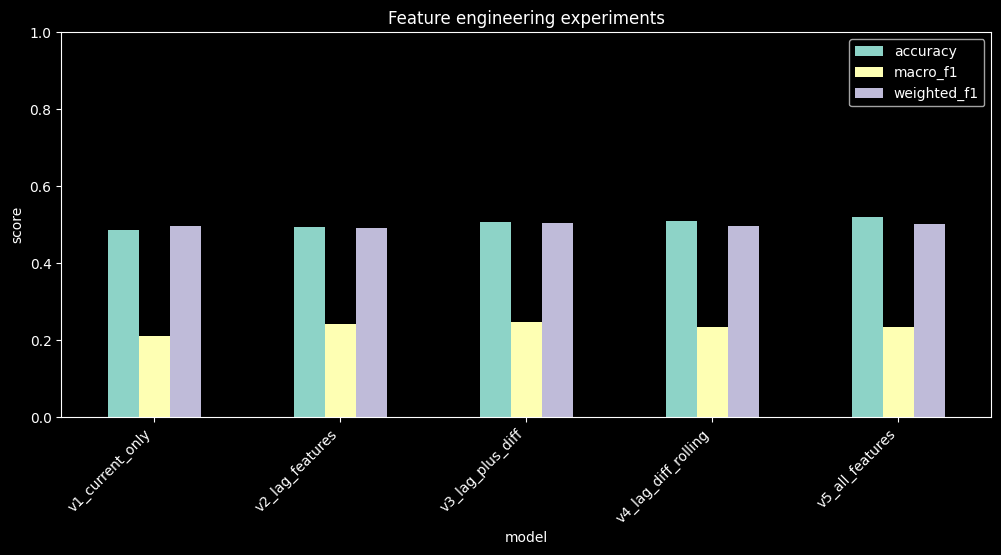

In [10]:
plot_df = experiment_results.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Feature engineering experiments")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()